**Table of contents**<a id='toc0_'></a>    
- 1. [Ngân hàng](#toc1_)    
  - 1.1. [Toàn ngành](#toc1_1_)    
  - 1.2. [Chart](#toc1_2_)    
- 2. [Chứng khoán](#toc2_)    
  - 2.1. [Toàn ngành](#toc2_1_)    
  - 2.2. [Chart](#toc2_2_)    
- 3. [Bảo hiểm](#toc3_)    
  - 3.1. [Toàn ngành](#toc3_1_)    
  - 3.2. [Chart](#toc3_2_)  
- 4. [Toàn bộ tài chính](#toc4_)      
  - 4.1. [Toàn ngành](#toc4_1_)    
  - 4.2. [Chart](#toc4_2_)
<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [25]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Đoạn này chưa rõ cách sử dụng
import sys
from dash import Dash, html, dcc, callback, Output, Input


In [26]:
import matplotlib.pyplot as plt

In [27]:
# syspath = r"D:\OneDrive\Data\Python_custom_respository"
# if syspath not in sys.path:
#     sys.path.append(syspath)

# from utils.drawing import FPTSTemplate, FPTSBlue, FPTSGreen

# pio.templates["FPTS"] = FPTSTemplate
# pio.templates.default = "FPTS"

In [28]:
PATH = r"D:\OneDrive - fpts.com.vn\14. Phan quyen thuc tap\Bao cao Cap nhat Ket qua kinh doanh\00.data\datanormalized_24Q4.xlsx"
NHPL_SHEET_NAME = "nhpl"
BHPL_SHEET_NAME = "bhpl"
CKPL_SHEET_NAME = "ckpl"
NHBS_SHEET_NAME = "nhbs"
BHBS_SHEET_NAME = "bhbs"
CKBS_SHEET_NAME = "ckbs"
NI = "Lợi nhuận sau thuế thu nhập doanh nghiệp"
NI_GROWTH = "Tăng trưởng LNST YoY"
EQUITY = "Vốn chủ sở hữu"
GICS1 = "GICS1_name"
GICS3 = "GICS3_name"
DVTM = 10**9
# NUMBER_OF_PERIODS = 20
CURRENT_DATE = pd.to_datetime("2024-12-31")

In [29]:
def logit(x):
    return 1 / (10 ** (-x) + 1) - 0.5


In [30]:
logit_ticklabel = np.hstack([[-100, -2], np.linspace(-1, 1, 11), [2, 100]]).round(1)
logit_tickval = logit(logit_ticklabel)


In [31]:
def cagr(data: pd.DataFrame):
    n = data.shape[0]
    return (data.iloc[-1] / data.iloc[0]) ** (4 / n) - 1


In [32]:
def current_yoy_growth(data: pd.DataFrame):
    yoy_growth: pd.DataFrame = data.groupby(level=0).pct_change(4)
    current_growth: pd.DataFrame = yoy_growth.loc(axis=0)[:, CURRENT_DATE]
    current_growth.index = current_growth.index.get_level_values(0)
    return current_growth


def summary(data: pd.DataFrame):
    current_growth = current_yoy_growth(data)
    current_ni: pd.DataFrame = data.loc(axis=0)[:, CURRENT_DATE][NI]
    current_ni.index = current_ni.index.get_level_values(0)
    summary = current_growth.rename(columns={NI: NI_GROWTH}).join(
        current_ni
    )
    return summary


In [33]:
# Giới hạn ngành với các mã sau

list_BH = ['ABI','AIC','BIC','BLI','BMI','BVH','MIG','PGI','PRE','PTI','PVI','VNR'
]
list_NH = ['ABB','ACB','BAB','BID','BVB','CTG','EIB','HDB','KLB','LPB','MBB','MSB','NAB','NVB','OCB','PGB','SGB','SHB','SSB','STB','TCB','TPB','VAB','VBB','VCB','VIB','VPB'
]
list_CK = ['AAS','AGR','APG','APS','BMS','BSI','BVS','CSI','CTS','DSC','EVS','FTS','HAC','HBS','HCM','IVS','MBS','ORS','PHS','PSI','SBS','SHS','SSI','TCI','TVB','TVS','VCI','VDS','VFS','VIG','VIX','VND','VUA','WSS'
]
list_TC = list_CK + list_NH + list_BH

Top_10_CTCK = ["HCM","FTS","MBS","BSI","VDS","VCI","SSI","VND","VIX","SHS"]

# 1. <a id='toc1_'></a>[Ngân hàng](#toc0_)

## 1.1. <a id='toc1_1_'></a>[Toàn ngành](#toc0_)

In [34]:
# nhpl = pd.read_excel(
#     PATH, sheet_name=NHPL_SHEET_NAME, header=0, index_col=0, parse_dates=True
# )
# nhpl


In [104]:
# nhbs = pd.read_excel(
#     PATH, sheet_name=NHBS_SHEET_NAME, header=0, index_col=0, parse_dates=True
# )
# nhbs

In [36]:
Banking = pd.read_excel(r"D:\Download\data_bank_24Q4.xlsx", sheet_name = "Dataraw_Q")
Banking = Banking.sort_values(by=['ticker', 'period'])
Banking 

,ticker,period,TickerPeriod,year,quarter,bs_tscd,bs_tscdhh,bs_tscdttc,bs_tscdvh,bs_bdsdt,...,Tỷ lệ bao phủ nợ xấu,Tăng trưởng thu nhập hoạt động (qoq),Tăng trưởng lợi nhuận trước thuế (qoq),Tỷ lệ CIR,ROA,ROE,Tỷ lệ CASA,Bình quân huy động vốn (LTM),Chi phí vốn COF,NIM
0,ABB,2019-Q1,ABB2019-Q1,2019,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABB,2019-Q2,ABB2019-Q2,2019,2,NaN,NaN,NaN,NaN,NaN,...,0.678228,NaN,3.288267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABB,2019-Q3,ABB2019-Q3,2019,3,NaN,NaN,NaN,NaN,NaN,...,0.649298,NaN,-0.243393,0.479635,NaN,NaN,NaN,NaN,NaN,NaN
3,ABB,2019-Q4,ABB2019-Q4,2019,4,NaN,NaN,NaN,NaN,NaN,...,0.557613,0.193699,0.138434,0.570646,0.011022,0.136187,0.000000,8.841052e+13,NaN,0.027916
4,ABB,2020-Q1,ABB2020-Q1,2020,1,NaN,NaN,NaN,NaN,NaN,...,0.555451,-0.178785,-0.010496,0.477590,0.013581,0.166702,0.123905,8.570132e+13,NaN,0.026767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,VPB,2023-Q4,VPB2023-Q4,2023,4,NaN,NaN,NaN,NaN,NaN,...,0.516835,0.184612,-0.131301,0.271003,0.011463,0.074715,0.174207,6.153226e+14,0.062378,0.053882
644,VPB,2024-Q1,VPB2024-Q1,2024,1,NaN,NaN,NaN,NaN,NaN,...,0.534364,0.005207,0.544343,0.258494,0.012826,0.080992,0.144124,6.409249e+14,0.059150,0.053557
645,VPB,2024-Q2,VPB2024-Q2,2024,2,NaN,NaN,NaN,NaN,NaN,...,0.480790,0.202629,0.072119,0.206542,0.013777,0.085233,0.178769,6.632975e+14,0.053139,0.056003
646,VPB,2024-Q3,VPB2024-Q3,2024,3,NaN,NaN,NaN,NaN,NaN,...,0.506973,-0.066034,0.156907,0.249018,0.019332,0.092686,0.140823,6.751974e+14,0.047708,0.058268


In [102]:
# nhpl_adjust = nhpl[ (nhpl['Ticker'].isin(list_NH))]
# nhbs_adjust = nhbs[ (nhbs['Ticker'].isin(list_NH))]

In [103]:
# sum_nhpl = nhpl_adjust.drop(columns=['Ticker']).groupby(nhpl_adjust.index).sum()
# sum_nhbs = nhbs_adjust.drop(columns=['Ticker']).groupby(nhbs_adjust.index).sum()

In [39]:
Banking['ticker'].value_counts()

ticker
ABB    24
ACB    24
BAB    24
BID    24
BVB    24
CTG    24
EIB    24
HDB    24
KLB    24
LPB    24
MBB    24
MSB    24
NAB    24
NVB    24
OCB    24
PGB    24
SGB    24
SHB    24
SSB    24
STB    24
TCB    24
TPB    24
VAB    24
VBB    24
VCB    24
VIB    24
VPB    24
Name: count, dtype: int64

In [40]:
Banking['COF'] = Banking.groupby('ticker').apply(lambda x: x["Chi phí lãi và các khoản chi phí tương tự"].rolling(4).sum() / x['Huy động vốn'].rolling(4).mean()).reset_index(level=0, drop=True)

C:\Users\Nhinty\AppData\Local\Temp\ipykernel_20308\3768391508.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Banking['COF'] = Banking.groupby('ticker').apply(lambda x: x["Chi phí lãi và các khoản chi phí tương tự"].rolling(4).sum() / x['Huy động vốn'].rolling(4).mean()).reset_index(level=0, drop=True)


In [41]:
# Chuyển đổi tất cả các cột từ cột thứ 6 trở đi thành kiểu số 
Banking.iloc[:, 5:] = Banking.iloc[:, 5:].apply(pd.to_numeric, errors='coerce')
Banking['fiscalDate'] = pd.to_datetime(Banking['period'].apply(lambda x: pd.Period(x, freq='Q').end_time)).dt.date
Banking.set_index('fiscalDate', inplace=True)
Banking = Banking.fillna(0)
Banking

C:\Users\Nhinty\AppData\Local\Temp\ipykernel_20308\1858833226.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Banking = Banking.fillna(0)


,ticker,period,TickerPeriod,year,quarter,bs_tscd,bs_tscdhh,bs_tscdttc,bs_tscdvh,bs_bdsdt,...,Tăng trưởng thu nhập hoạt động (qoq),Tăng trưởng lợi nhuận trước thuế (qoq),Tỷ lệ CIR,ROA,ROE,Tỷ lệ CASA,Bình quân huy động vốn (LTM),Chi phí vốn COF,NIM,COF
fiscalDate,,,,,,,,,,,,,,,,,,,,,
2019-03-31,ABB,2019-Q1,ABB2019-Q1,2019,1,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
2019-06-30,ABB,2019-Q2,ABB2019-Q2,2019,2,0.0,0.0,0.0,0.0,0.0,...,0.000000,3.288267,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
2019-09-30,ABB,2019-Q3,ABB2019-Q3,2019,3,0.0,0.0,0.0,0.0,0.0,...,0.000000,-0.243393,0.479635,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
2019-12-31,ABB,2019-Q4,ABB2019-Q4,2019,4,0.0,0.0,0.0,0.0,0.0,...,0.193699,0.138434,0.570646,0.011022,0.136187,0.000000,8.841052e+13,0.000000,0.027916,0.000000
2020-03-31,ABB,2020-Q1,ABB2020-Q1,2020,1,0.0,0.0,0.0,0.0,0.0,...,-0.178785,-0.010496,0.477590,0.013581,0.166702,0.123905,8.570132e+13,0.000000,0.026767,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31,VPB,2023-Q4,VPB2023-Q4,2023,4,0.0,0.0,0.0,0.0,0.0,...,0.184612,-0.131301,0.271003,0.011463,0.074715,0.174207,6.153226e+14,0.062378,0.053882,0.062378
2024-03-31,VPB,2024-Q1,VPB2024-Q1,2024,1,0.0,0.0,0.0,0.0,0.0,...,0.005207,0.544343,0.258494,0.012826,0.080992,0.144124,6.409249e+14,0.059150,0.053557,0.059150
2024-06-30,VPB,2024-Q2,VPB2024-Q2,2024,2,0.0,0.0,0.0,0.0,0.0,...,0.202629,0.072119,0.206542,0.013777,0.085233,0.178769,6.632975e+14,0.053139,0.056003,0.053139


In [42]:
# Groupby theo cột 'period/fiscalDate' và tính tổng cho các cột từ cột thứ 6 trở đi
Banking_groupby = Banking.groupby(Banking.index).apply(lambda x: x.iloc[:, 5:].sum())
Banking_groupby.index = pd.to_datetime(Banking_groupby.index)

In [43]:
# Chuyển đổi đơn vị cho tiện hiển thị (tỷ VND)
Banking_groupby = Banking_groupby/ DVTM

In [44]:
eqvni_nh = pd.DataFrame({
    'lnst_nh': Banking_groupby["pl_lnst"],
    'vcsh_nh': Banking_groupby["bs_vcsh"]
})
eqvni_nh["ROE_NH"] = eqvni_nh["lnst_nh"]/eqvni_nh["vcsh_nh"].rolling(2).mean()
eqvni_nh = eqvni_nh[eqvni_nh.index > '2019-12-31']
eqvni_nh

,lnst_nh,vcsh_nh,ROE_NH
fiscalDate,,,
2020-03-31,23609.159979,6.401551e+05,0.037468
2020-06-30,26578.214311,6.669832e+05,0.040666
2020-09-30,26389.284390,6.952125e+05,0.038745
2020-12-31,34007.462621,7.233302e+05,0.047947
2021-03-31,41875.551023,7.599499e+05,0.056463
2021-06-30,37438.604370,7.950506e+05,0.048153
2021-09-30,31523.465982,8.328830e+05,0.038728
2021-12-31,36323.872244,8.885846e+05,0.042201
2022-03-31,54842.077557,9.458307e+05,0.059792


In [45]:
# Tỷ lệ YoY ở hiện tại đối với từng chỉ tiêu
sum_nhpl_yoy = Banking_groupby.pct_change(4)
sum_nhpl_yoy_current = sum_nhpl_yoy.loc[CURRENT_DATE]

sum_nhpl_yoy_current[["pl_lnst","Thu nhập lãi thuần"]]

pl_lnst               0.196878
Thu nhập lãi thuần    0.112671
Name: 2024-12-31 00:00:00, dtype: float64

In [46]:
# sum_nhpl["TNNL"] = sum_nhpl["Tổng thu nhập hoạt động"] - sum_nhpl["Thu nhập lãi thuần"]
# sum_nhbs["Huy động vốn"] = sum_nhbs["Tiền gửi của khách hàng"] + sum_nhbs["Tiền gửi và vay các TCTD khác"] + sum_nhbs["Phát hành giấy tờ có giá"]
# sum_nhbs["BQ vốn huy động (LTM)"] = sum_nhbs["Huy động vốn"].rolling(window=4).mean()

In [47]:
Banking_groupby["CASA"] = (Banking_groupby["Tiền gửi ko kì hạn (Khách hàng)"] + Banking_groupby["Tiền gửi kí quỹ"])/ Banking_groupby["Tiền gửi khách hàng"]
Banking_groupby["TSSL"] = Banking_groupby[["Tiền gửi tại NHNN","Tiền gửi và cho vay tại các tổ chức tín dụng khác", "Cho vay và cho thuê tài chính khách hàng (chưa tính dự phòng)","Chứng khoán kinh doanh","Chứng khoán đầu tư"]].sum(axis=1).rolling(window=4).mean()
Banking_groupby["NIM"] = Banking_groupby["Thu nhập lãi thuần"].rolling(window=4).sum() / Banking_groupby['TSSL']
Banking_groupby["Tỷ lệ nợ xấu toàn ngành"] = (Banking_groupby[['Nợ có khả năng mất vốn','Nợ dưới tiêu chuẩn', 'Nợ nghi ngờ']].sum(axis=1))/(Banking_groupby[['Nợ đủ tiêu chuẩn', 'Nợ cần chú ý','Nợ có khả năng mất vốn','Nợ dưới tiêu chuẩn', 'Nợ nghi ngờ']].sum(axis=1))
Banking_groupby["COF toàn ngành"] = Banking_groupby["Chi phí lãi và các khoản chi phí tương tự"].rolling(window=4).sum() / Banking_groupby['Huy động vốn'].rolling(4).mean()


In [48]:
corr_CASA_COF = Banking.loc[Banking['period'] == '2024-Q4', ['ticker', 'Tỷ lệ CASA', "COF"]]
corr_CASA_COF

,ticker,Tỷ lệ CASA,COF
fiscalDate,,,
2024-12-31,ABB,0.125801,0.042405
2024-12-31,ACB,0.224529,0.033856
2024-12-31,BAB,0.029233,0.060075
2024-12-31,BID,0.197199,0.035883
2024-12-31,BVB,0.067167,0.048805
2024-12-31,CTG,0.242170,0.032230
2024-12-31,EIB,0.147236,0.038451
2024-12-31,HDB,0.119448,0.048097
2024-12-31,KLB,0.064324,0.048052


In [49]:
# Pivot dữ liệu
Banking_pivot = Banking.pivot(index='ticker', columns='period', values='Tỷ lệ bao phủ nợ xấu (LLCR)')
print(Banking_pivot[['2023-Q4', '2024-Q4']].reset_index())

period ticker   2023-Q4   2024-Q4
0         ABB  0.463948  0.455376
1         ACB  0.911627  0.779172
2         BAB  1.310177  0.974449
3         BID  1.818336  1.336847
4         BVB  0.418423  0.452129
5         CTG  1.672228  1.707452
6         EIB  0.412083  0.423160
7         HDB  0.658195  0.687055
8         KLB  0.622255  0.836551
9         LPB  0.937534  0.823898
10        MBB  1.169808  0.922484
11        MSB  0.551937  0.643783
12        NAB  0.516473  0.528298
13        NVB  0.065462  0.086021
14        OCB  0.503497  0.471388
15        PGB  0.389900  0.404975
16        SGB  0.441401  0.362535
17        SHB  0.777108  0.651084
18        SSB  0.855016  0.828779
19        STB  0.688453  0.684304
20        TCB  1.020416  1.139406
21        TPB  0.637088  0.813122
22        VAB  0.668246  0.725039
23        VBB  0.375578  0.460112
24        VCB  2.302992  2.233110
25        VIB  0.510033  0.498746
26        VPB  0.516835  0.561749


## 1.2. <a id='toc1_2_'></a>[Chart](#toc0_)

In [50]:
fig_1 = px.bar(Banking_groupby[['Thu nhập lãi thuần', 'Thu nhập ngoài lãi']])
fig_1.update_layout(
    yaxis_title="Tỷ VND",  # Thêm đơn vị vào tiêu đề trục Y
    yaxis_tickformat=",.0f"  # Định dạng số với dấu phẩy hàng nghìn
)

In [51]:
fig_2 = px.bar(Banking_groupby["Cho vay khách hàng tổng (đã tính dự phòng)"])
fig_2.update_layout(
    yaxis_title="Tỷ VND",  # Thêm đơn vị vào tiêu đề trục Y
    yaxis_tickformat=",.0f"  # Định dạng số với dấu phẩy hàng nghìn
)

In [52]:
fig_3 = px.bar(Banking_groupby[["Tiền gửi khách hàng","Tiền gửi và vay của TCTD khác","Phát hành giấy tờ có giá"]])
fig_3.update_layout(
    yaxis_title="Tỷ VND",  # Thêm đơn vị vào tiêu đề trục Y
    yaxis_tickformat=",.0f"  # Định dạng số với dấu phẩy hàng nghìn
)

In [53]:
fig_4 = px.line(Banking_groupby[['CASA','COF toàn ngành']])
fig_4.update_layout(
    title="Tương quan CASA & COF toàn ngành Q4/2024",
    yaxis={"tickformat": ".0%"},
    yaxis2={
        "overlaying": "y",  # Trục y phụ sẽ chồng lên trục y chính
        "side": "right",  # Trục y phụ sẽ nằm ở bên phải
        "tickformat": ".1%",  # Định dạng phần trăm cho trục y phụ
    },
)
# Gắn mỗi trace (line) vào một trục y khác nhau
fig_4.update_traces(
    yaxis="y2", selector=dict(name='COF toàn ngành')  # Gắn trace 'CASA' vào trục y phụ
)

In [54]:
fig_6 = px.scatter(
    corr_CASA_COF,
    y = "Tỷ lệ CASA",	
    x = "COF",
    text=corr_CASA_COF["ticker"],
    # template=FPTSTemplate,
)
textposi = ["middle right"] * 10
textposi[8:10] = ["middle left"] * 2
textposi[6] = "middle left"
textposi[0] = "middle left"
fig_6.update_traces(
    textfont={"size": 18},
    textposition=textposi,
    # marker={"color": [FPTSGreen] * 2 + [FPTSBlue[0]] * 8},
)
fig_6.update_layout(
    title="Tương quan CASA & COF các ngân hàng Q4/2024",
    xaxis={"tickformat": ".1%"},
    yaxis={"tickformat": ".0%"},
)


In [55]:
fig_7 = px.line(Banking_groupby["NIM"])
fig_7.update_layout(
    yaxis_tickformat=".1%"  
)

In [56]:
fig_8 = px.line(Banking_groupby["Tỷ lệ nợ xấu toàn ngành"])
fig_8.update_layout(
    yaxis_tickformat=".1%"  
)

In [57]:
Banking_pivot = Banking_pivot.sort_values(by='2024-Q4', ascending=False)
fig_9 = px.bar(Banking_pivot[['2024-Q4', '2023-Q4']])
fig_9.update_layout(
    title="Tỷ lệ bao phủ nợ xấu phân hóa giữa các ngân hàng",  
    yaxis_tickformat=",.0%",
    barmode='group'
)

# 2. <a id='toc2_'></a>[Chứng khoán](#toc0_)

## 2.1. <a id='toc2_1_'></a>[Toàn ngành](#toc0_)

In [58]:
DTMG = "Doanh thu môi giới chứng khoán cho người đầu tư" 
Lai_TD = "Lãi từ các tài sản tài chính ghi nhận thông qua lãi/lỗ ( FVTPL)"
Lo_TD = "Lỗ các tài sản tài chính ghi nhận thông qua lãi lỗ (FVTPL)"
DTCV = "Lãi từ các khoản cho vay và phải thu "
TDTHDKD = "Tổng doanh thu hoạt động kinh doanh"

In [59]:
ckpl = pd.read_excel(
    PATH, sheet_name=CKPL_SHEET_NAME, header=0, index_col=0, parse_dates=True
)
ckpl

,Ticker,Tổng doanh thu hoạt động kinh doanh,Lãi từ các tài sản tài chính ghi nhận thông qua lãi/lỗ ( FVTPL),Lãi bán các tài sản tài chính PVTPL,Chênh lệch tăng đánh giá lại các TSTC thông qua lãi/lỗ,"Cổ tức, tiền lãi phát sinh từ tài sản tài chính PVTPL",Lãi từ các khoản đầu tư nắm giữ đến ngày đáo hạn,Lãi từ các khoản cho vay và phải thu,Lãi từ chứng khoán Nợ đầu tư sẵn sàng để bán,Lãi từ các công cụ phát sinh phòng ngừa rủi ro,...,Lãi/(Lỗ) từ đánh giá lại các các khoản đầu tư giữ đến ngày đáo hạn,Lãi/(Lỗ) từ đánh giá lại các tài sản tài chính sẵn sàng để bán,"Lãi (lỗ) toàn diện khác được chia từ hoạt động đầu tư vào công ty con, liên kết liên doanh","Lãi, lỗ từ các khoản đầu tư vào công ty con. Công ty liên kết, liên doanh chưa chia",Tổng thu nhập toàn diện,Thu nhập toàn diện phân bổ cho chủ sở hữu,Thu nhập toàn diện phân bổ cho cổ đông không nắm quyền kiểm soát,THU NHẬP THUẦN TRÊN CỔ PHIẾU PHỔ THÔNG,Lãi cơ bản trên cổ phiếu,Lãi suy giảm trên cổ phiếu
fiscalDate,,,,,,,,,,,,,,,,,,,,,
2020-03-31,ABW,19.135946,1.261984,0.321998,0.003426,0.936559,0.000000,10.101921,0.000000,0.0,...,0.0,0.000000,0.0,0.0,2.151480,2.151480,0.0,0.000000e+00,5.400000e-08,0.0
2020-03-31,APG,4.954636,0.000000,0.000000,0.000000,0.000000,4.102700,0.098956,0.000000,0.0,...,0.0,0.000000,0.0,0.0,2.511116,2.511116,0.0,0.000000e+00,7.400000e-08,0.0
2020-03-31,APS,40.041892,1.170206,1.172204,-0.002092,0.000093,0.000000,2.351318,0.000000,0.0,...,0.0,0.000000,0.0,0.0,2.470028,2.470028,0.0,0.000000e+00,0.000000e+00,0.0
2020-03-31,ART,106.743060,72.055033,0.000000,72.055014,0.000018,7.680822,13.476110,0.000000,0.0,...,0.0,45.985848,0.0,0.0,7.947836,7.947836,0.0,-8.670000e-07,-8.670000e-07,0.0
2020-03-31,BMS,59.872486,57.163183,56.595881,0.000000,0.567302,0.679452,0.752106,0.000000,0.0,...,0.0,0.000000,0.0,0.0,-37.694351,-37.694351,0.0,0.000000e+00,0.000000e+00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,VIG,6.195075,0.000000,0.000000,0.000000,0.000000,3.932055,0.000000,1.137302,0.0,...,0.0,0.000000,0.0,0.0,-2.919114,-2.919114,0.0,-6.500000e-08,-6.500000e-08,0.0
2024-12-31,VIX,544.617506,360.778542,80.286768,231.144267,49.347506,6.402981,144.075082,0.000000,0.0,...,0.0,0.000000,0.0,0.0,112.200364,112.200364,0.0,0.000000e+00,0.000000e+00,0.0
2024-12-31,VND,1211.805941,606.096955,374.759603,132.328469,99.008883,64.203143,326.639967,0.000000,0.0,...,0.0,0.000000,0.0,0.0,251.319288,251.319288,0.0,0.000000e+00,1.470000e-07,0.0


In [60]:
ckpl.groupby('fiscalDate')['Ticker'].nunique()

fiscalDate
2020-03-31    35
2020-06-30    35
2020-09-30    35
2020-12-31    35
2021-03-31    35
2021-06-30    35
2021-09-30    35
2021-12-31    35
2022-03-31    35
2022-06-30    35
2022-09-30    35
2022-12-31    35
2023-03-31    35
2023-06-30    35
2023-09-30    35
2023-12-31    35
2024-03-31    35
2024-06-30    35
2024-09-30    35
2024-12-31    35
Name: Ticker, dtype: int64

In [61]:
ckbs = pd.read_excel(
    PATH, sheet_name=CKBS_SHEET_NAME, header=0, index_col=0, parse_dates=True
)
ckbs


,Ticker,TỔNG CỘNG TÀI SẢN,Tài sản ngắn hạn,Tài sản tài chính ngắn hạn,Tiền và các khoản tương đương tiền,Các khoản đầu tư tài chính ngắn hạn,Các khoản phải thu ngắn hạn,Hàng tồn kho,Tài sản ngắn hạn khác,Tạm ứng,...,Quỹ đầu tư phát triển,Quỹ dự phòng tài chính,Quỹ khác thuộc vốn chủ sở hữu,Lợi nhuận sau thuế chưa phân phối,Lợi ích cổ đông không kiểm soát,Nguồn kinh phí và quỹ khác,Vốn ngân sách nhà nước,"Quỹ khen thưởng, phúc lợi (trước 2010)",Lợi ích của cổ đông không kiểm soát (trước 2015),Lợi nhuận đã phân phối cho Nhà đầu tư trong năm
fiscalDate,,,,,,,,,,,,,,,,,,,,,
2020-03-31,ABW,646.382925,482.815421,478.361263,77.626439,343.732639,57.002185,0.0,4.454158,0.867001,...,0.0,5.315205,0.000000,46.496062,0.0,0.0,0.0,0.0,0.0,0.0
2020-03-31,APG,392.523482,152.782203,152.015186,0.546938,72.559833,78.908415,0.0,0.767017,0.493805,...,0.0,0.445000,0.000000,35.835605,0.0,0.0,0.0,0.0,0.0,0.0
2020-03-31,APS,361.973092,347.366167,300.835837,11.528368,261.066765,28.240704,0.0,46.530330,46.198481,...,0.0,2.868000,0.000000,-53.062107,0.0,0.0,0.0,0.0,0.0,0.0
2020-03-31,ART,1107.869769,1030.606249,1028.849311,210.740897,806.240315,11.868099,0.0,1.756938,0.355440,...,0.0,7.295112,0.220341,104.421511,0.0,0.0,0.0,0.0,0.0,0.0
2020-03-31,BMS,571.612446,545.778815,544.152694,3.341597,271.662275,269.148823,0.0,1.626121,0.105000,...,0.0,12.238583,0.000000,30.228660,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,VIG,372.936251,224.572668,224.524213,50.187871,111.247000,63.089342,0.0,0.048456,0.028456,...,0.0,1.813982,0.000000,-113.150860,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-31,VIX,19606.325398,19558.155309,19555.958327,693.527828,18710.234089,152.196411,0.0,2.196982,0.275000,...,0.0,86.480740,2.462262,1165.122864,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-31,VND,44294.776672,43105.620017,42935.352781,881.175660,40301.512735,1752.664385,0.0,170.267237,10.532344,...,0.0,0.000000,0.000000,4492.240692,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
Du_no = pd.read_excel(r"D:\OneDrive - fpts.com.vn\14. Phan quyen thuc tap\Bao cao Cap nhat Ket qua kinh doanh\00.data\Dư nơ_VCSH_NganhCK.xlsx")
Du_no

,Ticker,year,period,bs_vcsh,Dư nợ cho vay (VNĐ)
0,AAS,2020,2020-Q4,346537705538,2.747380e+10
1,AGR,2020,2020-Q4,2096628990546,7.390120e+11
2,APG,2020,2020-Q4,401371761486,1.635938e+10
3,APS,2020,2020-Q4,400171766063,1.604491e+11
4,BMS,2020,2020-Q4,635999260944,4.738059e+09
...,...,...,...,...,...
573,VIG,2024,2024-Q4,356435953562,0.000000e+00
574,VIX,2024,2024-Q4,16044740899438,5.773917e+12
575,VND,2024,2024-Q4,19715068693211,1.034363e+13
576,VUA,2024,2024-Q4,267880135443,6.542897e+09


In [63]:
KL_GTGD = pd.read_excel(r"D:\OneDrive - fpts.com.vn\10. Khac\NhiNTY\BCKD\Other\Thanh khoản CK.xlsx", sheet_name="Final")
KL_GTGD

,Năm,Quý,period,KLGD/phiên,GTGD/phiên
0,2020,Q1,2020-Q1,1.831904e+08,1.577534e+11
1,2020,Q2,2020-Q2,3.073236e+08,2.555287e+11
2,2020,Q3,2020-Q3,2.771390e+08,2.407209e+11
3,2020,Q4,2020-Q4,4.576386e+08,4.571401e+11
4,2021,Q1,2021-Q1,6.403739e+08,7.402681e+11
5,2021,Q2,2021-Q2,7.035892e+08,9.115396e+11
6,2021,Q3,2021-Q3,6.516905e+08,8.704413e+11
7,2021,Q4,2021-Q4,8.801900e+08,1.274715e+12
8,2022,Q1,2022-Q1,7.932587e+08,1.182082e+12
9,2022,Q2,2022-Q2,5.823424e+08,7.690821e+11


In [64]:
ckpl = ckpl[ (ckpl['Ticker'].isin(list_CK))]
ckbs = ckbs[ (ckbs['Ticker'].isin(list_CK))]

In [65]:
ckpl["LNTD"] = ckpl[Lai_TD] - ckpl[Lo_TD]
sum_ckpl = ckpl.drop(columns=['Ticker']).groupby(ckpl.index).sum()
sum_ckbs = ckbs.drop(columns=['Ticker']).groupby(ckbs.index).sum()
# Tỷ lệ YoY ở hiện tại đối với từng chỉ tiêu
sum_ckpl_yoy = sum_ckpl.pct_change(4)
sum_ckpl_yoy_current = sum_ckpl_yoy.loc[CURRENT_DATE]

sum_ckpl_yoy_current[[TDTHDKD, NI, DTMG, DTCV, "LNTD"]]

C:\Users\Nhinty\AppData\Local\Temp\ipykernel_20308\1136069208.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Tổng doanh thu hoạt động kinh doanh                0.087804
Lợi nhuận sau thuế thu nhập doanh nghiệp          -0.176226
Doanh thu môi giới chứng khoán cho người đầu tư   -0.132972
Lãi từ các khoản cho vay và phải thu               0.272019
LNTD                                              -0.330772
Name: 2024-12-31 00:00:00, dtype: float64

In [66]:
sum_ckpl['period'] = sum_ckpl.index.to_period('Q').strftime('%Y-Q%q')
sum_ckbs['period'] = sum_ckbs.index.to_period('Q').strftime('%Y-Q%q')
ckpl['period'] = ckpl.index.to_period('Q').strftime('%Y-Q%q')
ckbs['period'] = ckbs.index.to_period('Q').strftime('%Y-Q%q')

C:\Users\Nhinty\AppData\Local\Temp\ipykernel_20308\1748453964.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Nhinty\AppData\Local\Temp\ipykernel_20308\1748453964.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [67]:
eqvni_ck = pd.DataFrame({
    'lnst_ck': sum_ckpl[NI],
    'vcsh_ck': sum_ckbs[EQUITY]
})
eqvni_ck["ROE_CK"] = eqvni_ck["lnst_ck"]/eqvni_ck["vcsh_ck"].rolling(2).mean()
eqvni_ck

,lnst_ck,vcsh_ck,ROE_CK
fiscalDate,,,
2020-03-31,-143.678437,42961.381069,NaN
2020-06-30,2115.889853,44537.249108,0.048364
2020-09-30,1563.504779,45242.572467,0.034830
2020-12-31,2568.343604,48374.860285,0.054869
2021-03-31,3180.006579,41127.752549,0.071060
2021-06-30,3732.490230,56939.467595,0.076121
2021-09-30,3392.766245,67214.861902,0.054654
2021-12-31,5512.257427,80197.832225,0.074787
2022-03-31,4185.080220,85014.490876,0.050663


In [68]:
DTMG_GTGD_merge = pd.merge(KL_GTGD, sum_ckpl, on=['period'], how = 'inner')
DTMG_GTGD_merge["DTMG/GTGD"] = DTMG_GTGD_merge[DTMG]*(10**9)/ DTMG_GTGD_merge["GTGD/phiên"]
result_dtmg_gtgd = DTMG_GTGD_merge[["period", "GTGD/phiên" ,"DTMG/GTGD"]]
result_dtmg_gtgd

,period,GTGD/phiên,DTMG/GTGD
0,2020-Q1,1.577534e+11,4.187923
1,2020-Q2,2.555287e+11,3.660378
2,2020-Q3,2.407209e+11,3.967157
3,2020-Q4,4.571401e+11,3.263156
4,2021-Q1,7.402681e+11,2.749567
5,2021-Q2,9.115396e+11,3.060881
6,2021-Q3,8.704413e+11,3.416376
7,2021-Q4,1.274715e+12,2.886083
8,2022-Q1,1.182082e+12,2.514775
9,2022-Q2,7.690821e+11,2.824947


In [69]:
du_no_pl_merge = pd.merge(Du_no, ckpl, on=['period','Ticker'], how = 'inner')
lai_suat_final = du_no_pl_merge[["period" ,"Dư nợ cho vay (VNĐ)", DTCV]]
sum_lai_suat= lai_suat_final.groupby('period').sum()
sum_lai_suat['rate'] = (1 + ((10**9) * sum_lai_suat[DTCV] )/ sum_lai_suat["Dư nợ cho vay (VNĐ)"].rolling(2).mean())**4 -1
sum_lai_suat

,Dư nợ cho vay (VNĐ),Lãi từ các khoản cho vay và phải thu,rate
period,,,
2020-Q4,4.847630e+13,1144.211063,NaN
2021-Q1,5.820753e+13,1414.755919,0.110385
2021-Q2,7.496985e+13,1924.864226,0.120738
2021-Q3,8.382686e+13,2233.064642,0.117335
2021-Q4,1.077890e+14,2864.768866,0.125077
2022-Q1,1.077676e+14,2863.128008,0.110570
2022-Q2,7.682888e+13,2559.724664,0.115633
2022-Q3,8.354440e+13,2247.692185,0.116926
2022-Q4,6.076077e+13,2092.473936,0.121147


In [70]:
sum_du_no = Du_no.drop(columns=['Ticker', 'year']).groupby('period').sum()
sum_du_no["du_no/vcsh"] = sum_du_no["Dư nợ cho vay (VNĐ)"] / sum_du_no['bs_vcsh']
sum_du_no

,bs_vcsh,Dư nợ cho vay (VNĐ),du_no/vcsh
period,,,
2020-Q4,50818026981563,4.924279e+13,0.969002
2021-Q1,55868366407150,5.916186e+13,1.058951
2021-Q2,59526886848697,7.609037e+13,1.278252
2021-Q3,70508469603402,8.535189e+13,1.210520
2021-Q4,83836325211797,1.097223e+14,1.308768
2022-Q1,88836363909488,1.096682e+14,1.234497
2022-Q2,98646417329799,7.838103e+13,0.794565
2022-Q3,109024071866849,8.550093e+13,0.784239
2022-Q4,109948627294845,6.178984e+13,0.561988


In [71]:
Du_no['Dư nợ/ VCSH'] = Du_no["Dư nợ cho vay (VNĐ)"] / (Du_no['bs_vcsh'])
ck_pivot = Du_no.pivot(index='Ticker', columns='period', values='Dư nợ/ VCSH')
print(ck_pivot[ck_pivot.index.isin(Top_10_CTCK)][['2023-Q4', '2024-Q4']].reset_index())

period Ticker   2023-Q4   2024-Q4
0         BSI  0.917026  1.027324
1         FTS  1.480289  1.716416
2         HCM  1.459937  1.956017
3         MBS  1.829719  1.490001
4         SHS  0.373667  0.373582
5         SSI  0.651183  0.820028
6         VCI  1.084279  0.866921
7         VDS  1.142161  0.978108
8         VIX  0.340679  0.359864
9         VND  0.622716  0.524656


## 2.2. <a id='toc2_2_'></a>[Chart](#toc0_)

<Axes: xlabel='fiscalDate'>

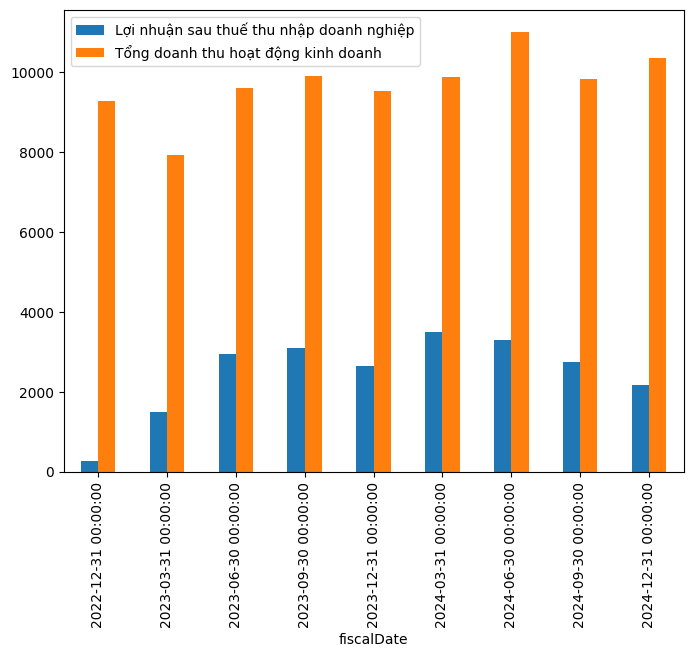

In [72]:
sum_ckpl[sum_ckpl.index >= '2022-12-31'][["Lợi nhuận sau thuế thu nhập doanh nghiệp","Tổng doanh thu hoạt động kinh doanh"]].plot(kind='bar', figsize=(8, 6))

In [73]:
px.bar(sum_ckpl[DTMG])

Text(0.5, 1.0, 'DTMG/GTGD')

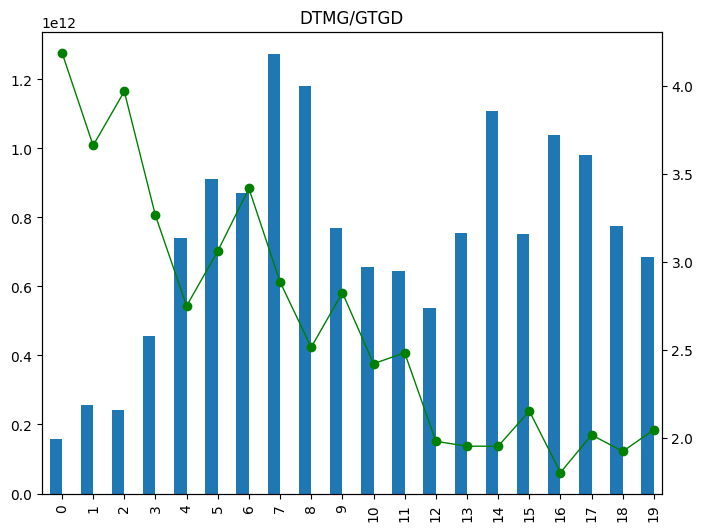

In [74]:
fig, ax1 = plt.subplots(figsize=(8, 6))

# Vẽ cột cho dư nợ
result_dtmg_gtgd["GTGD/phiên"].plot(kind='bar', ax=ax1, width=0.4, position=1)

# Tạo trục phụ để vẽ đường cho ratio
ax2 = ax1.twinx()
result_dtmg_gtgd["DTMG/GTGD"].plot(kind='line', ax=ax2, color='green', marker='o', linewidth=1)
plt.title('DTMG/GTGD')

Text(0.5, 1.0, 'LNTD')

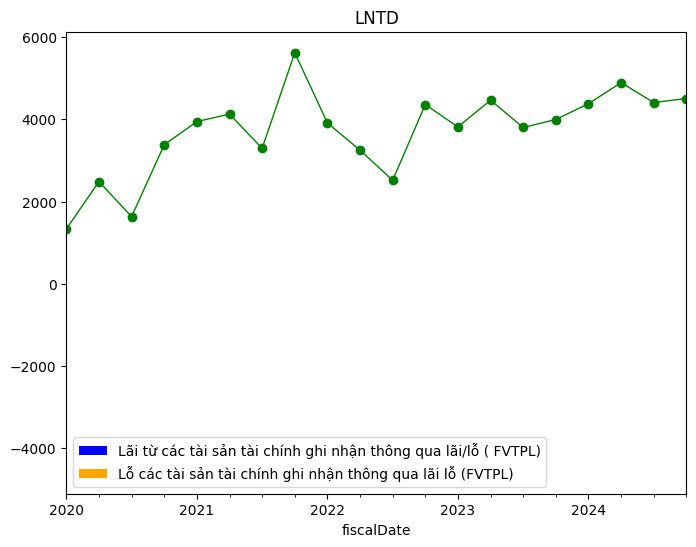

In [75]:
# Đổi dấu các giá trị trong cột B
sum_ckpl[Lo_TD] = -sum_ckpl[Lo_TD]

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(8, 6))

# Vẽ cột cho A và B
sum_ckpl[[Lai_TD, Lo_TD]].plot(kind='bar', stacked=True, ax=ax, position=1, width=0.4, color=['blue', 'orange'])

# Vẽ đường cho C
sum_ckpl[Lai_TD].plot(kind='line', ax=ax, color='green', marker='o', linewidth=1)
plt.title('LNTD')

In [76]:
px.bar(sum_ckpl[DTCV])

Text(0.5, 1.0, 'Dư nợ/ Vốn chủ sở hữu')

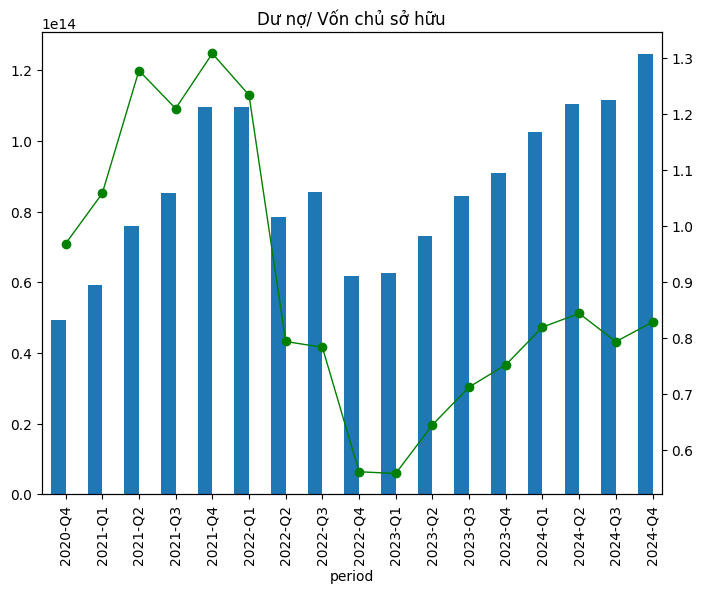

In [77]:
fig, ax1 = plt.subplots(figsize=(8, 6))

# Vẽ cột cho dư nợ
sum_du_no["Dư nợ cho vay (VNĐ)"].plot(kind='bar', ax=ax1, width=0.4, position=1)

# Tạo trục phụ để vẽ đường cho ratio
ax2 = ax1.twinx()
sum_du_no["du_no/vcsh"].plot(kind='line', ax=ax2, color='green', marker='o', linewidth=1)
plt.title('Dư nợ/ Vốn chủ sở hữu')

Text(0.5, 1.0, 'Lãi suất trên dư nợ')

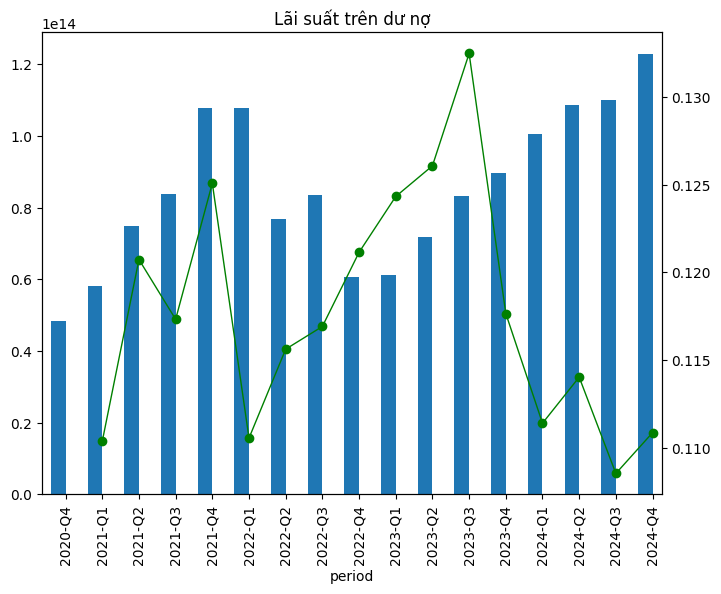

In [78]:
fig, ax1 = plt.subplots(figsize=(8, 6))

# Vẽ cột cho dư nợ
sum_lai_suat["Dư nợ cho vay (VNĐ)"].plot(kind='bar', ax=ax1, width=0.4, position=1)

# Tạo trục phụ để vẽ đường cho ratio
ax2 = ax1.twinx()
sum_lai_suat["rate"].plot(kind='line', ax=ax2, color='green', marker='o', linewidth=1)
plt.title('Lãi suất trên dư nợ')

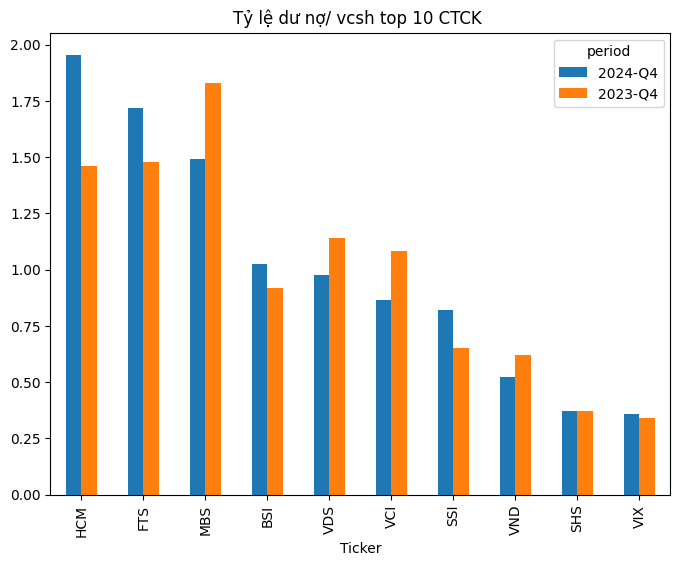

In [79]:
top_10 = ck_pivot[ck_pivot.index.isin(Top_10_CTCK)][['2024-Q4', '2023-Q4']].sort_values(by='2024-Q4', ascending=False)
top_10.plot(kind='bar', figsize=(8, 6))

plt.title('Tỷ lệ dư nợ/ vcsh top 10 CTCK ')
plt.show()

# 3. <a id='toc3_'></a>[Bảo hiểm](#toc0_)

## 3.1. <a id='toc3_1_'></a>[Toàn ngành](#toc0_)

In [80]:
bhpl = pd.read_excel(
    PATH, sheet_name=BHPL_SHEET_NAME, header=0, index_col=0, parse_dates=True
)
bhpl


,Ticker,Doanh thu phí bảo hiểm,Thu phí bảo hiểm gốc,Thu phí nhận tái bảo hiểm,Tăng (giảm) dự phòng phí bảo hiểm gốc và nhận tái bảo hiểm,Các khoản giảm trừ doanh thu,Phí nhượng tái bảo hiểm,Dự phòng phí nhượng tái bảo hiểm,Giảm phí,Hoàn phí,...,Lợi nhuận kế toán trước thuế,Dự phòng đảm bảo cân đối,Chi phí thuế TNDN,Chi phí thuế TNDN hiện hành,Chi phí thuế TNDN hoãn lại,Lợi nhuận sau thuế thu nhập doanh nghiệp,Lợi ích của cổ đông thiểu số,Lợi nhuận sau thuế của Công ty mẹ,Lãi cơ bản trên cổ phiếu,Chi phí của hoạt động ngân hàng
fiscalDate,,,,,,,,,,,,,,,,,,,,,
2020-03-31,ABI,412.253060,473.049098,0.219543,61.015581,24.719751,21.723600,-2.996152,-2.996152,0.000000,...,102.329981,0,20.509230,20.509230,0.000000,81.820751,0.000000,81.820751,0.000000e+00,0
2020-03-31,AIC,295.631474,344.867286,6.877909,56.113722,73.995590,105.034147,31.038558,31.038558,0.000000,...,-35.250434,0,0.000000,0.000000,0.000000,-35.250434,0.000000,-35.250434,0.000000e+00,0
2020-03-31,BIC,491.301684,594.564577,-64.926950,38.335943,153.552610,128.567674,-24.984936,-24.984936,0.000000,...,84.375156,0,21.319186,21.319186,0.000000,63.055970,0.945780,62.110190,0.000000e+00,0
2020-03-31,BLI,309.175964,287.078347,26.920697,4.823080,141.656890,123.546081,204.336084,0.000000,-18.110810,...,16.745421,0,2.942568,5.348583,-2.406015,13.802852,0.000000,13.802852,2.300000e-07,0
2020-03-31,BMI,1205.730122,1037.007725,129.267712,-39.454686,311.255377,263.215672,-48.039705,0.000000,-48.039705,...,51.088357,0,10.182633,10.182633,0.000000,40.905724,0.000000,40.905724,3.610000e-07,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,MIG,1366.555358,1344.366492,23.007465,0.818599,676.009032,635.250768,-40.758264,-40.758264,0.000000,...,100.745134,0,20.505095,20.382538,0.122557,80.240038,0.000000,80.240038,0.000000e+00,0
2024-12-31,PGI,1173.819424,1199.818024,13.187660,39.186260,390.592824,420.036021,29.443197,29.443197,0.000000,...,48.591087,0,11.080818,11.036458,0.044359,37.510270,0.000000,37.510270,0.000000e+00,0
2024-12-31,PRE,523.333032,0.000000,471.775196,-51.557837,327.633443,237.073513,-90.559930,0.000000,-90.559930,...,88.807349,0,17.934427,17.934427,0.000000,70.872923,0.000000,70.872923,6.550000e-07,0


In [81]:
bhbs = pd.read_excel(
    PATH, sheet_name=BHBS_SHEET_NAME, header=0, index_col=0, parse_dates=True
)
bhbs


,Ticker,TỔNG CỘNG TÀI SẢN,Tài sản ngắn hạn,Tiền và các khoản tương đương tiền,Tiền,Các khoản tương đương tiền,Các khoản đầu tư tài chính ngắn hạn,Đầu tư ngắn hạn,Dự phòng giảm giá đầu tư ngắn hạn,Đầu tư giữ đến ngày đáo hạn,...,Nguồn kinh phí và quỹ khác,Nguồn kinh phí đã hình thành TSCĐ,Lợi ích của cổ đông không kiểm soát (trước 2015),Nợ khó đòi đã xử lý,Hợp đồng bảo hiểm chưa phát sinh trách nhiệm,Ngoại tệ các loại,Đô la Mỹ (USD),Đồng Euro (EUR),Đồng Yên Nhật (JPY),Ngoại tệ khác
fiscalDate,,,,,,,,,,,,,,,,,,,,,
2020-03-31,ABI,2679.873083,2501.333713,80.566547,80.252605,0.313942,1975.247292,0.000000,0.000000,1975.247292,...,0.0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2020-03-31,AIC,2159.492120,1710.595037,182.223376,182.223376,0.000000,427.134486,449.116730,-21.982244,0.000000,...,0.0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2020-03-31,BIC,5496.932152,3722.092200,125.001862,115.001862,10.000000,1942.548371,199.322763,-24.946536,1768.172143,...,0.0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2020-03-31,BLI,1991.904225,1649.134243,79.802882,79.802882,0.000000,931.089641,69.632532,-26.909380,888.366489,...,0.0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2020-03-31,BMI,5991.939144,5007.641120,236.765485,236.765485,0.000000,2283.187242,267.950800,-117.666941,2132.903383,...,0.0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,MIG,9834.946333,9130.648855,329.566433,329.566433,0.000000,4113.000000,0.000000,0.000000,4113.000000,...,0.0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2024-12-31,PGI,8424.810637,7108.186167,150.043598,150.043598,0.000000,4128.836279,4131.659490,-2.823211,0.000000,...,0.0,0,0.0,43.011734,95.755135,0.000533,0.000516,0.000017,0.0,0.0
2024-12-31,PRE,6700.999105,5717.559646,8.678819,8.678819,0.000000,2229.124600,0.000000,0.000000,2229.124600,...,0.0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0


In [82]:
bhpl.groupby('fiscalDate')['Ticker'].nunique()

fiscalDate
2020-03-31    11
2020-06-30    11
2020-09-30    11
2020-12-31    11
2021-03-31    11
2021-06-30    11
2021-09-30    11
2021-12-31    11
2022-03-31    11
2022-06-30    11
2022-09-30    11
2022-12-31    11
2023-03-31    11
2023-06-30    11
2023-09-30    11
2023-12-31    11
2024-03-31    11
2024-06-30    11
2024-09-30    11
2024-12-31    11
Name: Ticker, dtype: int64

In [83]:
bhpl["Hoạt động đầu tư"] = bhpl["Doanh thu hoạt động tài chính"] + bhpl["Doanh thu kinh doanh bất động sản đầu tư"]
bhpl["LN hoạt động đầu tư"] = bhpl["Lợi nhuận hoạt động tài chính"] + bhpl["Lợi nhuận từ hoạt động đầu tư bất động sản"]
bhpl["Tổng DT"] = bhpl["Doanh thu thuần"] + bhpl["Hoạt động đầu tư"]
bhbs["Đầu tư ngắn hạn"] = bhbs["Tiền và các khoản tương đương tiền"] + bhbs["Các khoản đầu tư tài chính ngắn hạn"]
bhbs["Đầu tư dài hạn"] = bhbs["Bất động sản đầu tư"] + bhbs["Các khoản đầu tư tài chính dài hạn"]
bhbs["Tổng các khoản đầu tư"] = bhbs["Đầu tư ngắn hạn"] + bhbs["Đầu tư dài hạn"]

In [84]:
sum_bhpl = bhpl.drop(columns=['Ticker']).groupby(bhpl.index).sum()
sum_bhbs = bhbs.drop(columns=['Ticker']).groupby(bhbs.index).sum()
# Tỷ lệ YoY ở hiện tại đối với từng chỉ tiêu
sum_bhpl_yoy = sum_bhpl.pct_change(4)
sum_bhpl_yoy_current = sum_bhpl_yoy.loc[CURRENT_DATE]
 
sum_bhpl_yoy_current[["Doanh thu thuần", "Hoạt động đầu tư", NI,"Lợi nhuận gộp", "LN hoạt động đầu tư", "Chi phí quản lý doanh nghiệp" ]]

Doanh thu thuần                             0.014200
Hoạt động đầu tư                           -0.072825
Lợi nhuận sau thuế thu nhập doanh nghiệp    0.207697
Lợi nhuận gộp                               2.727053
LN hoạt động đầu tư                        -0.071001
Chi phí quản lý doanh nghiệp                0.199551
Name: 2024-12-31 00:00:00, dtype: float64

In [85]:
eqvni_bh = pd.DataFrame({
    'lnst_bh': sum_bhpl[NI],
    'vcsh_bh': sum_bhbs[EQUITY]
})
eqvni_bh["ROE_BH"] = eqvni_bh["lnst_bh"]/eqvni_bh["vcsh_bh"].rolling(2).mean()
eqvni_bh

,lnst_bh,vcsh_bh,ROE_BH
fiscalDate,,,
2020-03-31,455.200972,35632.009499,NaN
2020-06-30,1168.522302,36063.992947,0.032597
2020-09-30,966.350522,36935.960016,0.026475
2020-12-31,900.958007,37329.730986,0.024263
2021-03-31,1079.336944,36520.600083,0.029230
2021-06-30,1049.545902,38504.268119,0.027979
2021-09-30,1171.827988,39561.723379,0.030021
2021-12-31,1041.520824,39828.678739,0.026238
2022-03-31,1158.645227,40980.251584,0.028676


In [86]:
# Tỷ lệ các khoản đầu tư
Ty_le_dau_tu = sum_bhbs[["Đầu tư ngắn hạn", "Đầu tư dài hạn","Tổng các khoản đầu tư"]]
Ty_le_dau_tu["short_rate"] = Ty_le_dau_tu["Đầu tư ngắn hạn"]/Ty_le_dau_tu["Tổng các khoản đầu tư"]
Ty_le_dau_tu["long_rate"] = Ty_le_dau_tu["Đầu tư dài hạn"]/Ty_le_dau_tu["Tổng các khoản đầu tư"]
Ty_le_dau_tu

C:\Users\Nhinty\AppData\Local\Temp\ipykernel_20308\981882778.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Nhinty\AppData\Local\Temp\ipykernel_20308\981882778.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Đầu tư ngắn hạn,Đầu tư dài hạn,Tổng các khoản đầu tư,short_rate,long_rate
fiscalDate,,,,,
2020-03-31,97573.308010,47923.628020,145496.936030,0.670621,0.329379
2020-06-30,105503.815362,46059.666110,151563.481472,0.696103,0.303897
2020-09-30,110587.941224,49066.711598,159654.652822,0.692670,0.307330
2020-12-31,101798.872474,59693.138533,161492.011007,0.630365,0.369635
2021-03-31,101514.742947,54063.070475,153719.919347,0.660388,0.351699
2021-06-30,101256.236294,64296.894755,165553.131049,0.611624,0.388376
2021-09-30,111877.800842,70500.639747,182378.440588,0.613438,0.386562
2021-12-31,113042.555298,74042.525850,187085.081148,0.604231,0.395769
2022-03-31,124518.724272,78290.574551,202809.298824,0.613970,0.386030


In [87]:
corr_bh = bhpl[['Ticker', 'Tổng DT', NI]].sort_values(by='Ticker', ascending=True).groupby('Ticker').apply(lambda x: x.sort_index(ascending=True)).reset_index(level='Ticker', drop=True)
corr_bh

C:\Users\Nhinty\AppData\Local\Temp\ipykernel_20308\834184701.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,Ticker,Tổng DT,Lợi nhuận sau thuế thu nhập doanh nghiệp
fiscalDate,,,
2020-03-31,ABI,429.728718,81.820751
2020-06-30,ABI,464.650982,84.281427
2020-09-30,ABI,469.080324,71.004604
2020-12-31,ABI,475.885278,55.913042
2021-03-31,ABI,470.886853,80.172730
...,...,...,...
2023-12-31,VNR,398.459955,52.596709
2024-03-31,VNR,664.944931,143.194157
2024-06-30,VNR,561.645112,156.419422


In [88]:
corr_bh["DT_yoy"]=corr_bh['Tổng DT'].pct_change(4)
corr_bh["NI_yoy"]=corr_bh[NI].pct_change(4)
corr_bh_yoy_current = corr_bh.loc[CURRENT_DATE]
corr_bh_yoy_current

,Ticker,Tổng DT,Lợi nhuận sau thuế thu nhập doanh nghiệp,DT_yoy,NI_yoy
fiscalDate,,,,,
2024-12-31,ABI,597.469886,74.675516,-0.032985,1.193294
2024-12-31,AIC,839.860171,31.978986,0.179720,0.856157
2024-12-31,BIC,1246.240685,151.836020,0.098808,0.192132
2024-12-31,BLI,343.634326,18.569313,-0.066995,-0.103588
2024-12-31,BMI,1335.120029,43.087995,0.012991,-0.424336
2024-12-31,BVH,13711.080955,538.875920,-0.011164,0.457552
2024-12-31,MIG,1126.869427,80.240038,0.066710,-0.268455
2024-12-31,PGI,935.397659,37.510270,-0.000519,0.016148
2024-12-31,PRE,350.048107,70.872923,-0.089766,-0.119833


## 3.2. <a id='toc3_2_'></a>[Chart](#toc0_)

<Axes: xlabel='fiscalDate'>

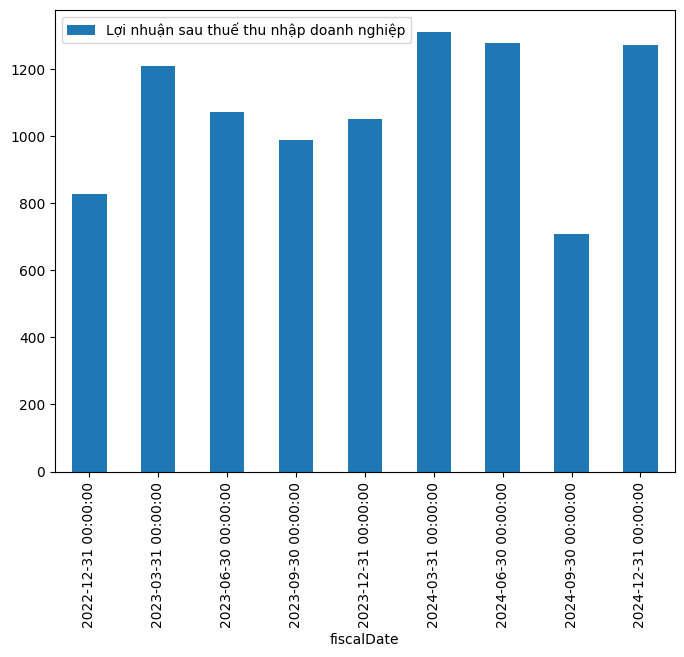

In [89]:
sum_bhpl[sum_bhpl.index >= '2022-12-31'][["Lợi nhuận sau thuế thu nhập doanh nghiệp"]].plot(kind='bar', figsize=(8, 6))

<Axes: xlabel='fiscalDate'>

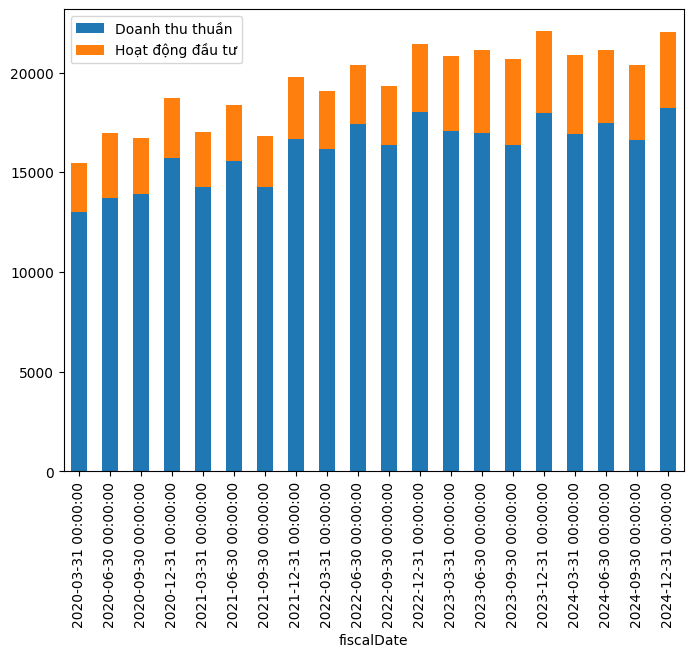

In [90]:
sum_bhpl[["Doanh thu thuần","Hoạt động đầu tư"]].plot(kind='bar',stacked= True,  figsize=(8, 6))

<Axes: xlabel='fiscalDate'>

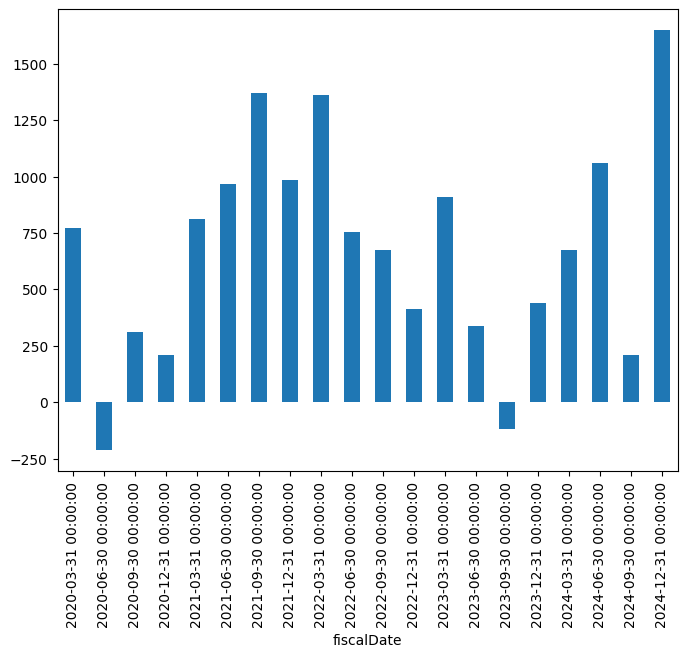

In [91]:
sum_bhpl["Lợi nhuận gộp"].plot(kind='bar',  figsize=(8, 6))

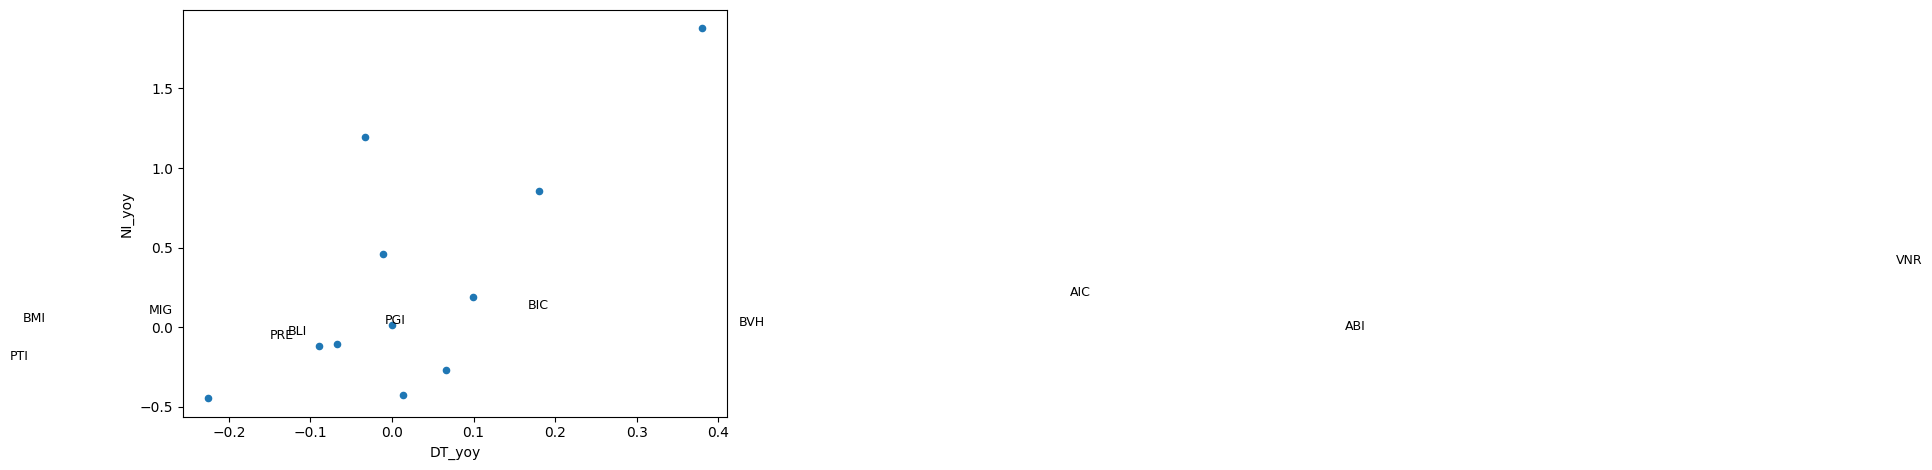

In [92]:
corr_bh_yoy_current.plot.scatter(y='NI_yoy', x='DT_yoy')
plt.tight_layout()
# Thêm tên ticker vào mỗi điểm
for index, row in corr_bh_yoy_current.iterrows():
    plt.text(row['NI_yoy'], row['DT_yoy'], row['Ticker'], fontsize=9, ha='right', va='bottom')

# 4. <a id='toc4_'></a>[Tài chính](#toc0_)

## 4.1. <a id='toc4_1_'></a>[Toàn ngành](#toc0_)

In [93]:
df = pd.concat([eqvni_nh, eqvni_ck, eqvni_bh], axis=1)
df

,lnst_nh,vcsh_nh,ROE_NH,lnst_ck,vcsh_ck,ROE_CK,lnst_bh,vcsh_bh,ROE_BH
fiscalDate,,,,,,,,,
2020-03-31,23609.159979,6.401551e+05,0.037468,-143.678437,42961.381069,NaN,455.200972,35632.009499,NaN
2020-06-30,26578.214311,6.669832e+05,0.040666,2115.889853,44537.249108,0.048364,1168.522302,36063.992947,0.032597
2020-09-30,26389.284390,6.952125e+05,0.038745,1563.504779,45242.572467,0.034830,966.350522,36935.960016,0.026475
2020-12-31,34007.462621,7.233302e+05,0.047947,2568.343604,48374.860285,0.054869,900.958007,37329.730986,0.024263
2021-03-31,41875.551023,7.599499e+05,0.056463,3180.006579,41127.752549,0.071060,1079.336944,36520.600083,0.029230
2021-06-30,37438.604370,7.950506e+05,0.048153,3732.490230,56939.467595,0.076121,1049.545902,38504.268119,0.027979
2021-09-30,31523.465982,8.328830e+05,0.038728,3392.766245,67214.861902,0.054654,1171.827988,39561.723379,0.030021
2021-12-31,36323.872244,8.885846e+05,0.042201,5512.257427,80197.832225,0.074787,1041.520824,39828.678739,0.026238
2022-03-31,54842.077557,9.458307e+05,0.059792,4185.080220,85014.490876,0.050663,1158.645227,40980.251584,0.028676


In [94]:
df["LNST ngành"] = df["lnst_bh"] + df["lnst_ck"] + df["lnst_nh"]
df["VCSH ngành"] = df["vcsh_bh"] + df["vcsh_ck"] + df["vcsh_nh"]
df["ROE ngành"] = df["LNST ngành"]/ df["VCSH ngành"] 
df

,lnst_nh,vcsh_nh,ROE_NH,lnst_ck,vcsh_ck,ROE_CK,lnst_bh,vcsh_bh,ROE_BH,LNST ngành,VCSH ngành,ROE ngành
fiscalDate,,,,,,,,,,,,
2020-03-31,23609.159979,6.401551e+05,0.037468,-143.678437,42961.381069,NaN,455.200972,35632.009499,NaN,23920.682513,7.187485e+05,0.033281
2020-06-30,26578.214311,6.669832e+05,0.040666,2115.889853,44537.249108,0.048364,1168.522302,36063.992947,0.032597,29862.626466,7.475845e+05,0.039945
2020-09-30,26389.284390,6.952125e+05,0.038745,1563.504779,45242.572467,0.034830,966.350522,36935.960016,0.026475,28919.139691,7.773910e+05,0.037200
2020-12-31,34007.462621,7.233302e+05,0.047947,2568.343604,48374.860285,0.054869,900.958007,37329.730986,0.024263,37476.764232,8.090348e+05,0.046323
2021-03-31,41875.551023,7.599499e+05,0.056463,3180.006579,41127.752549,0.071060,1079.336944,36520.600083,0.029230,46134.894547,8.375983e+05,0.055080
2021-06-30,37438.604370,7.950506e+05,0.048153,3732.490230,56939.467595,0.076121,1049.545902,38504.268119,0.027979,42220.640502,8.904943e+05,0.047413
2021-09-30,31523.465982,8.328830e+05,0.038728,3392.766245,67214.861902,0.054654,1171.827988,39561.723379,0.030021,36088.060214,9.396596e+05,0.038405
2021-12-31,36323.872244,8.885846e+05,0.042201,5512.257427,80197.832225,0.074787,1041.520824,39828.678739,0.026238,42877.650495,1.008611e+06,0.042512
2022-03-31,54842.077557,9.458307e+05,0.059792,4185.080220,85014.490876,0.050663,1158.645227,40980.251584,0.028676,60185.803004,1.071825e+06,0.056153


In [95]:
# Tỷ lệ YoY ở hiện tại đối với từng chỉ tiêu
df_yoy = df.pct_change(4)
df_yoy_current = df_yoy.loc[CURRENT_DATE]
df_yoy_current


lnst_nh       0.196878
vcsh_nh       0.168412
ROE_NH        0.019670
lnst_ck      -0.176226
vcsh_ck       0.252021
ROE_CK       -0.326766
lnst_bh       0.207697
vcsh_bh       0.056016
ROE_BH        0.145605
LNST ngành    0.179739
VCSH ngành    0.171826
ROE ngành     0.006753
Name: 2024-12-31 00:00:00, dtype: float64

## 4.2. <a id='toc4_2_'></a>[Chart](#toc0_)

In [96]:
px.bar(df[["lnst_nh","lnst_ck","lnst_bh"]])

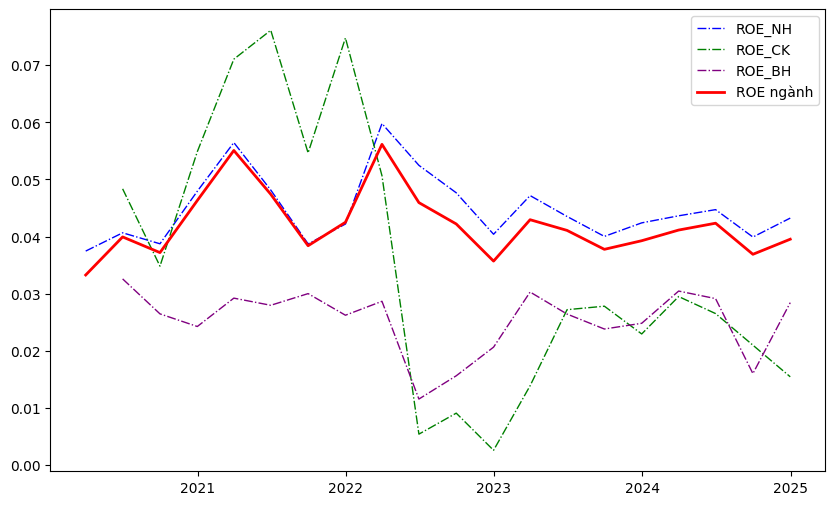

In [97]:
# Vẽ biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ các đường
plt.plot(df.index, df["ROE_NH"], label="ROE_NH", linestyle='-.', color='blue', linewidth=1)
plt.plot(df.index, df['ROE_CK'], label="ROE_CK",linestyle='-.', color='green', linewidth=1)
plt.plot(df.index, df['ROE_BH'], label="ROE_BH",linestyle='-.', color='purple', linewidth=1)  
plt.plot(df.index, df['ROE ngành'], label="ROE ngành", color='red', linewidth=2)
# Hiển thị chú thích
plt.legend()